### Dataset preview

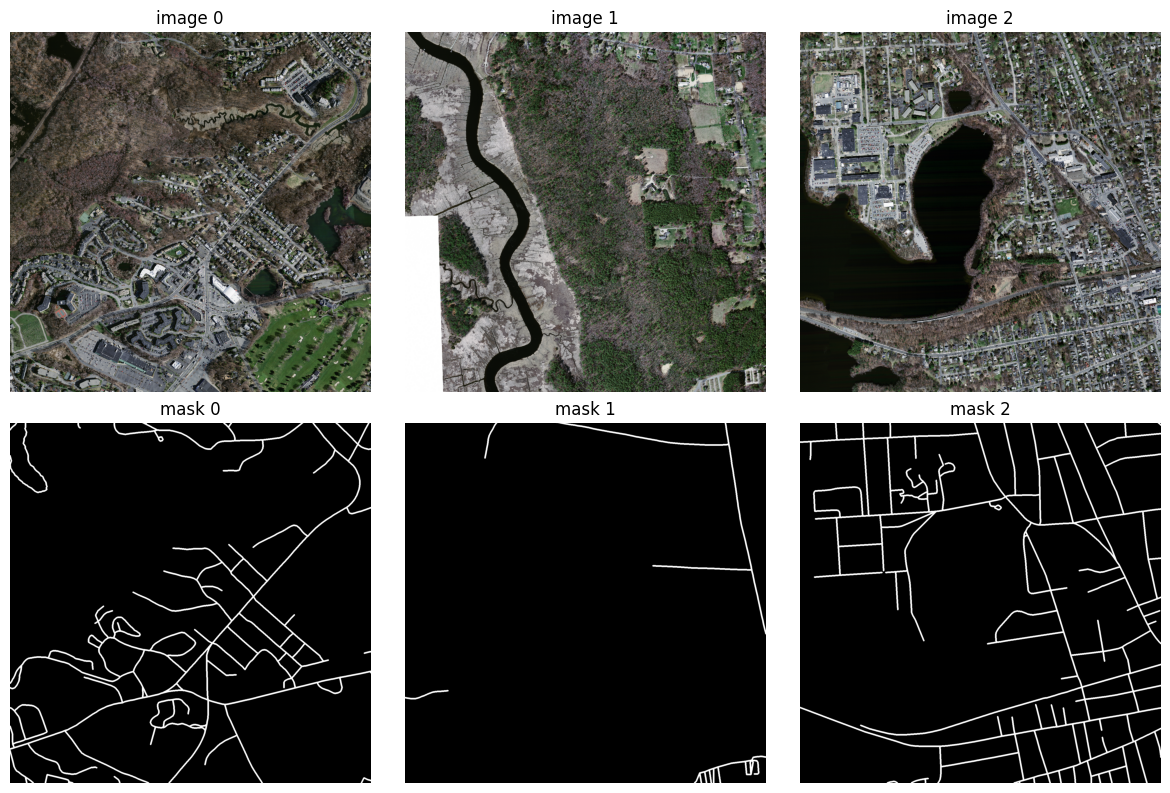

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from dataset import RoadsDataset

PREVIEW_IMG_DIR = "data/tiff/train/"
PREVIEW_MASK_DIR = "data/tiff/train_labels/"

raw_ds = RoadsDataset(PREVIEW_IMG_DIR, PREVIEW_MASK_DIR)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for col, idx in enumerate([0, 1, 2]):
    image, mask = raw_ds[idx]
    axes[0, col].imshow(image)
    axes[0, col].set_title(f"image {idx}")
    axes[1, col].imshow(mask, cmap="gray")
    axes[1, col].set_title(f"mask {idx}")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()

### Transform preview

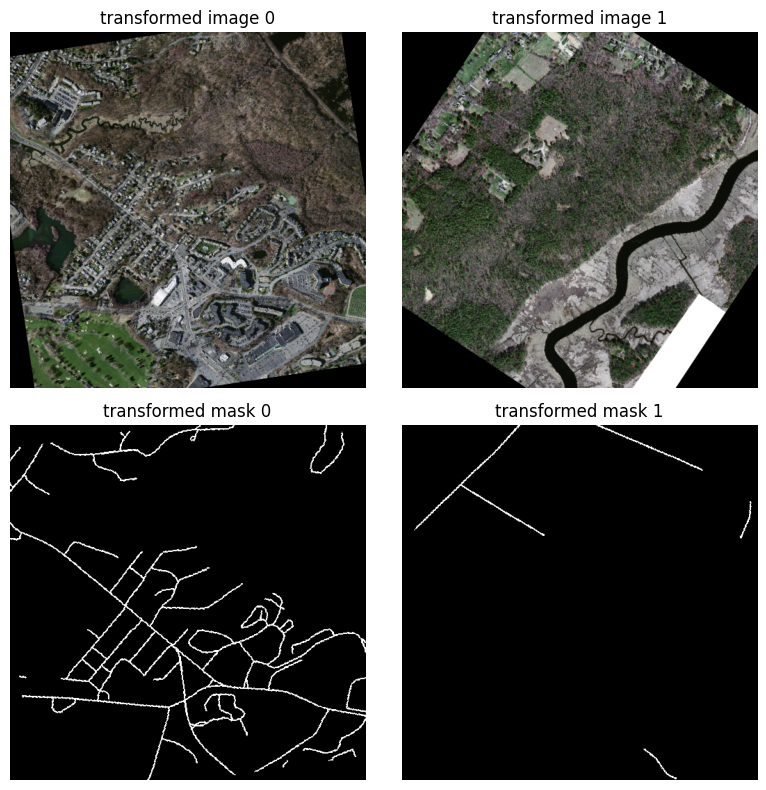

In [5]:
preview_transform = A.Compose(
    [
        A.Resize(height=512, width=512),
        A.Rotate(limit=35, p=1.0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.1),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
        ToTensorV2(),
    ]
)

transformed_ds = RoadsDataset(PREVIEW_IMG_DIR, PREVIEW_MASK_DIR, transform=preview_transform)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def show_tensor_image(tensor):
    image = (tensor.cpu() * std + mean).clamp(0, 1)
    return image.permute(1, 2, 0)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for col, idx in enumerate([0, 1]):
    image, mask = transformed_ds[idx]
    axes[0, col].imshow(show_tensor_image(image))
    axes[0, col].set_title(f"transformed image {idx}")
    axes[1, col].imshow(mask, cmap="gray")
    axes[1, col].set_title(f"transformed mask {idx}")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()

### Model
UNet-like architecture

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as tf

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.conv(x)
    
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64,128,256,512]):
        super().__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Down part of UNet
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Up part of UNet
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature*2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]

            if x.shape != skip_connection.shape:
                x = tf.resize(x, size=skip_connection.shape[2:])

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)

### Train loop

In [ ]:
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from utils import update_iou_stats

LEARNING_RATE = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 8
NUM_EPOCHS = 20
NUM_WORKERS = 4
IMAGE_HEIGHT = 512 # originally: 1500px
IMAGE_WIDTH = 512 # originally: 1500px
PIN_MEMORY = True
LOAD_MODEL = False

CHECKPOINT_PATH = "best_unet.pth"
TRAIN_IMG_DIR = "data/tiff/train/"
TRAIN_MASK_DIR = "data/tiff/train_labels/"
VAL_IMG_DIR = "data/tiff/val/"
VAL_MASK_DIR = "data/tiff/val_labels/"
TEST_IMG_DIR = "data/tiff/test/"
TEST_MASK_DIR = "data/tiff/test_labels/"

def train_one_epoch(model, loader, optimizer, loss_fn, scaler):
    model.train()

    total_loss = 0.0
    total_samples = 0

    total_intersection = 0.0
    total_union = 0.0

    loop = tqdm(loader)
    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(device=DEVICE)
        targets = targets.unsqueeze(1).to(device=DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            logits = model(data)
            loss = loss_fn(logits, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        intersection, union = update_iou_stats(logits, targets)
        total_intersection += intersection.item()
        total_union += union.item()

        # update tqdm loop
        loop.set_postfix(loss=loss.item())

    total_loss = total_loss / total_samples
    total_iou = total_intersection / (total_union + 1e-7)

    return total_loss, total_iou


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    
    total_loss = 0.0
    total_samples = 0

    total_intersection = 0.0
    total_union = 0.0

    for data, targets in loader:
        data = data.to(device=DEVICE)
        targets = targets.unsqueeze(1).to(device=DEVICE)

        logits = model(data)
        loss = loss_fn(logits, targets)

        batch_size = data.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        intersection, union = update_iou_stats(logits, targets)

        total_intersection += intersection.item()
        total_union += union.item()

    total_loss = total_loss / total_samples
    total_iou = total_intersection / (total_union + 1e-7)

    return total_loss, total_iou


train_transforms = A.Compose(
    [
        A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
        A.Rotate(limit=35, p=1.0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.1),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
        ToTensorV2(),
    ]
)

val_transforms = A.Compose(
    [
        A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
        ToTensorV2(),
    ]
)


In [3]:
from utils import get_loaders

model = UNet(in_channels=3, out_channels=1).to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_loader, val_loader, test_loader = get_loaders(
    TRAIN_IMG_DIR, TRAIN_MASK_DIR,
    VAL_IMG_DIR, VAL_MASK_DIR,
    TEST_IMG_DIR, TEST_MASK_DIR,
    BATCH_SIZE,
    train_transforms,
    val_transforms,
    NUM_WORKERS,
    PIN_MEMORY
)

scaler = torch.amp.GradScaler("cuda")

history = {
    "train_loss": [],
    "val_loss": [],
    "train_iou": [],
    "val_iou": [],
}
best_val_iou = 0.0

if LOAD_MODEL:
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    model.eval()
    print(f"Loaded model from {CHECKPOINT_PATH}")
else:

    for epoch in range(NUM_EPOCHS):
        train_loss, train_iou = train_one_epoch(model, train_loader, optimizer, loss_fn, scaler)
        val_loss, val_iou = evaluate(model, val_loader, loss_fn)

        history["train_loss"].append(train_loss)
        history["train_iou"].append(train_iou)
        history["val_loss"].append(val_loss)
        history["val_iou"].append(val_iou)

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), CHECKPOINT_PATH)

        print(
            f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
            f"train_loss={train_loss:.4f} | train_iou={train_iou:.4f} | "
            f"val_loss={val_loss:.4f} | val_iou={val_iou:.4f}"
        )


100%|██████████| 139/139 [03:15<00:00,  1.41s/it, loss=0.4]  


Epoch 1/20 | train_loss=0.4808 | train_iou=0.0512 | val_loss=0.4145 | val_iou=0.0006


100%|██████████| 139/139 [03:29<00:00,  1.51s/it, loss=0.337]


Epoch 2/20 | train_loss=0.3404 | train_iou=0.0032 | val_loss=0.3381 | val_iou=0.0351


100%|██████████| 139/139 [03:41<00:00,  1.59s/it, loss=0.249]


...

Epoch 18/20 | train_loss=0.0975 | train_iou=0.4046 | val_loss=0.1246 | val_iou=0.4427


100%|██████████| 139/139 [03:32<00:00,  1.53s/it, loss=0.1]   


Epoch 19/20 | train_loss=0.0958 | train_iou=0.4061 | val_loss=0.1209 | val_iou=0.4967


100%|██████████| 139/139 [03:21<00:00,  1.45s/it, loss=0.108] 


Epoch 20/20 | train_loss=0.0954 | train_iou=0.4007 | val_loss=0.1205 | val_iou=0.4624


### Training curves

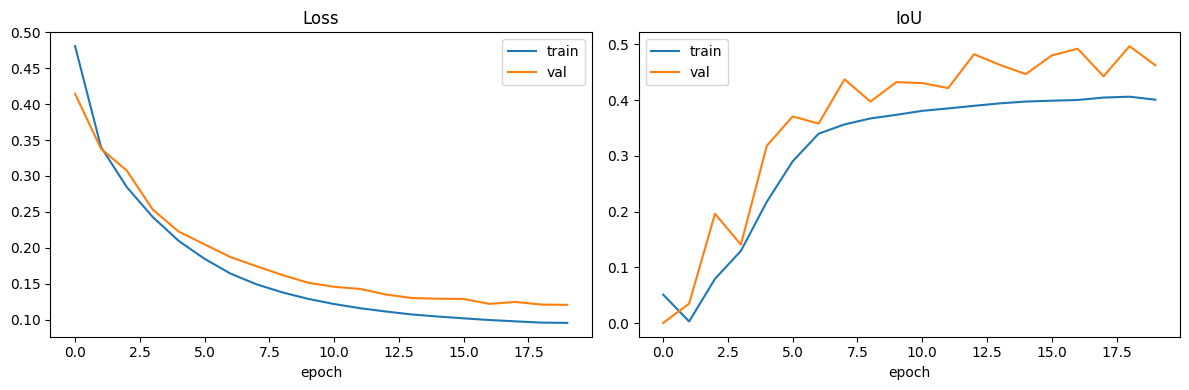

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["train_iou"], label="train")
axes[1].plot(history["val_iou"], label="val")
axes[1].set_title("IoU")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()

### Test metrics

In [9]:
test_loss, test_iou = evaluate(model, test_loader, loss_fn)
print(f"test_loss={test_loss:.4f} | test_iou={test_iou:.4f}")

test_loss=0.0825 | test_iou=0.5034


### Test predictions

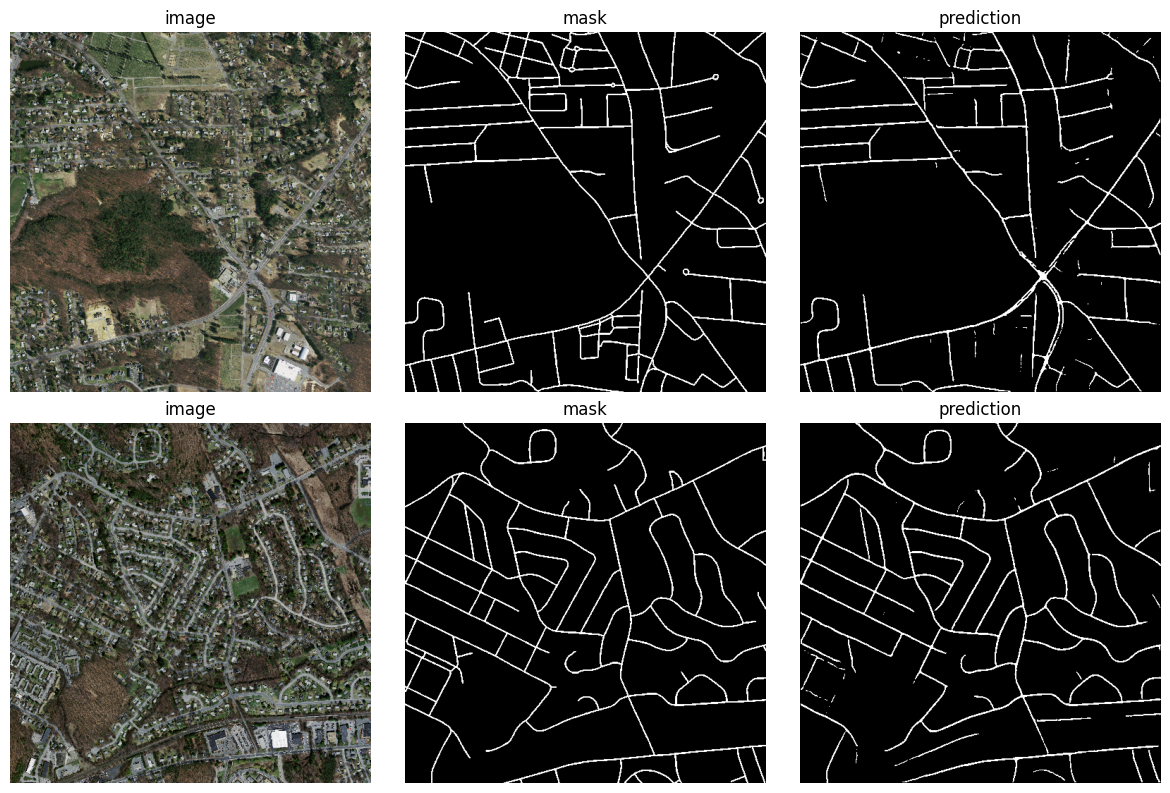

In [7]:
model.eval()
images, masks = next(iter(test_loader))
images = images.to(DEVICE)

with torch.no_grad():
    logits = model(images)
    preds = (torch.sigmoid(logits) > 0.5).float().cpu()

images = images.cpu()
masks = masks.cpu()

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for row in range(2):
    axes[row, 0].imshow(show_tensor_image(images[row]))
    axes[row, 0].set_title("image")
    axes[row, 1].imshow(masks[row], cmap="gray")
    axes[row, 1].set_title("mask")
    axes[row, 2].imshow(preds[row, 0], cmap="gray")
    axes[row, 2].set_title("prediction")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()